### Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

In [2]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)

PROCESSED = Path("../data/processed")

In [4]:
# ── Load global feature stats (from Global Kaggle preprocessing) ─────────────
# Global Kaggle had NO coordinates → its patterns are stored as JSON weights
import json

global_stats_path = PROCESSED / "global_feature_stats.json"
if global_stats_path.exists():
    with open(global_stats_path) as f:
        global_stats = json.load(f)

    # Build quick lookup dicts from the stats
    WEATHER_SEV_LOOKUP = {
        r["Weather Conditions"]: r["avg_severity"]
        for r in global_stats["weather_risk"]
    }
    ROAD_SEV_LOOKUP = {
        r["Road Type"]: r["avg_severity"]
        for r in global_stats["road_type_risk"]
    }
    CAUSE_SEV_LOOKUP = {
        r["Accident Cause"]: r["avg_severity"]
        for r in global_stats["cause_risk"]
    }
    print(" Global feature stats loaded from global_feature_stats.json")
    print(f"   Weather risk entries  : {len(WEATHER_SEV_LOOKUP)}")
    print(f"   Road type risk entries: {len(ROAD_SEV_LOOKUP)}")
    print(f"   Cause risk entries    : {len(CAUSE_SEV_LOOKUP)}")
    print()
    print("Weather severity lookup (from 132K global records):")
    for k, v in sorted(WEATHER_SEV_LOOKUP.items(), key=lambda x: -x[1]):
        print(f"   {k:<20} avg_severity = {v:.3f}")
else:
    print("⚠️  global_feature_stats.json not found.")
    print("    Run 02_preprocessing.ipynb first.")
    WEATHER_SEV_LOOKUP = {}
    ROAD_SEV_LOOKUP    = {}
    CAUSE_SEV_LOOKUP   = {}

 Global feature stats loaded from global_feature_stats.json
   Weather risk entries  : 5
   Road type risk entries: 3
   Cause risk entries    : 5

Weather severity lookup (from 132K global records):
   Snowy                avg_severity = 2.004
   Foggy                avg_severity = 2.003
   Clear                avg_severity = 1.997
   Rainy                avg_severity = 1.996
   Windy                avg_severity = 1.995


In [19]:
# Load cleaned data
df = pd.read_parquet(PROCESSED / "cleaned_spatial.parquet")
print(f"Loaded cleaned_spatial.parquet: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(df.dtypes.value_counts())
df.head(3)

Loaded cleaned_spatial.parquet: 5,898 rows × 20 cols
str        12
int64       5
float64     3
Name: count, dtype: int64


,latitude,longitude,severity,killed,injured,weather,road_type,road_condition,lighting,speed_limit,state,country,year,month,hour,cause,vehicle_type,crash_type,area_type,source
0,18.278457,76.009574,4,4,0,unknown,nh,unknown,unknown,NaN,Maharashtra,India,2022,January,-1,head on collision,car,head on collision,unknown,mendeley_india_2022_2023
1,24.543681,84.280571,4,6,18,unknown,nh,unknown,unknown,NaN,Jharkhand,India,2022,January,-1,head on collision,pick up,head on collision,unknown,mendeley_india_2022_2023
2,15.390068,73.854974,4,3,2,unknown,nh,unknown,unknown,NaN,Goa,India,2022,January,-1,fixed object collision,car,fixed object collision,unknown,mendeley_india_2022_2023


### 1. H3 Spatial Features

In [20]:
# H3 — Uber's hexagonal grid — divides earth into equal hex cells
# Resolution 9 ≈ 174m diameter — ideal for blackspot detection
import h3
H3_AVAILABLE = True

In [21]:
if H3_AVAILABLE:
    print("Assigning H3 cells (resolution 9)...")
    #------------------------------old not used now#
    # df["h3_r9"] = df.apply(
    #     lambda r: h3.geo_to_h3(r["latitude"], r["longitude"], 9), axis=1)
    # df["h3_r8"] = df.apply(
    #     lambda r: h3.geo_to_h3(r["latitude"], r["longitude"], 8), axis=1)
    #-------------------------------old not used now#
    df["h3_r9"] = df.apply(
    lambda r: h3.latlng_to_cell(r["latitude"], r["longitude"], 9), axis=1
    )
    df["h3_r8"] = df.apply(
        lambda r: h3.latlng_to_cell(r["latitude"], r["longitude"], 8), axis=1
    )
    # r8 ≈ 461m — coarser view for cluster detection
    print(f"  Unique H3-r9 cells: {df['h3_r9'].nunique():,}")
    print(f"  Unique H3-r8 cells: {df['h3_r8'].nunique():,}")
else:
    # Fallback: round coordinates to grid (~1km cells)
    df["h3_r9"] = (df["latitude"].round(2).astype(str) + "_" +
                   df["longitude"].round(2).astype(str))
    df["h3_r8"] = (df["latitude"].round(1).astype(str) + "_" +
                   df["longitude"].round(1).astype(str))
    print(f"  Grid cells r9 (~1km): {df['h3_r9'].nunique():,}")
    print(f"  Grid cells r8 (~10km): {df['h3_r8'].nunique():,}")

Assigning H3 cells (resolution 9)...
  Unique H3-r9 cells: 5,788
  Unique H3-r8 cells: 5,678


In [22]:
# ── Accident density per hex cell ─────────────────────────────
hex_density_r9 = df.groupby("h3_r9").size().rename("hex_density_r9")
hex_density_r8 = df.groupby("h3_r8").size().rename("hex_density_r8")

df = df.merge(hex_density_r9, on="h3_r9", how="left")
df = df.merge(hex_density_r8, on="h3_r8", how="left")

print("Hex density distribution (r9):")
print(df["hex_density_r9"].describe().round(2).to_string())
print()
print("Top 10 densest hex cells:")
print(hex_density_r9.nlargest(10).to_string())

Hex density distribution (r9):
count    5898.00
mean        1.04
std         0.21
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         3.00

Top 10 densest hex cells:
h3_r9
896088cde6bffff    3
89608bcecabffff    3
896099a2b63ffff    3
896099a2b7bffff    3
896099a3103ffff    3
896099a354bffff    3
89618eb1957ffff    3
893c8e41d27ffff    2
893c9034237ffff    2
893c9254c57ffff    2


In [23]:
# ── Hex severity score (avg severity per hex cell) ────────────
hex_sev = df.groupby("h3_r9")["severity"].mean().rename("hex_avg_severity")
df = df.merge(hex_sev, on="h3_r9", how="left")

# ── Hex fatality rate ─────────────────────────────────────────
hex_fat = df.groupby("h3_r9")["killed"].sum().rename("hex_total_killed")
df = df.merge(hex_fat, on="h3_r9", how="left")

print(" Spatial hex features created:")
# print(f"   hex_density_r9   : {df['hex_density_r9'].describe()['mean']:.2f} avg accidents/cell")
# print(f"   hex_avg_severity : {df['hex_avg_severity'].describe()['mean']:.2f} avg severity/cell")
# print(f"   hex_total_killed : {df['hex_total_killed'].describe()['sum']:.0f} total fatalities")
print(" Spatial hex features created:")
print(f"   hex_density_r9   : {df['hex_density_r9'].mean():.2f} avg accidents/cell")
print(f"   hex_avg_severity : {df['hex_avg_severity'].mean():.2f} avg severity/cell")
print(f"   hex_total_killed : {hex_fat.sum():.0f} total fatalities")

 Spatial hex features created:
 Spatial hex features created:
   hex_density_r9   : 1.04 avg accidents/cell
   hex_avg_severity : 2.63 avg severity/cell
   hex_total_killed : 13950 total fatalities


### Time based feature

In [24]:
# Hour bucket
def hour_to_bucket(h):
    if h < 0:    return "unknown"
    if h < 6:    return "night"
    if h < 12:   return "morning"
    if h < 18:   return "afternoon"
    return "evening"

df["hour_bucket"] = df["hour"].apply(hour_to_bucket)

# is_night: 20:00 – 05:59
df["is_night"] = ((df["hour"] >= 20) | (df["hour"] <= 5)).astype(int)
df.loc[df["hour"] < 0, "is_night"] = 0  # unknown hour

# is_weekend
WEEKEND = ["saturday","sunday"]
df["is_weekend"] = 0  # default
# if day_of_week column available from kaggle india
if "Day of Week" in df.columns:
    df["is_weekend"] = df["Day of Week"].str.lower().isin(WEEKEND).astype(int)

# is_monsoon: July, August, September, October
MONSOON = ["july","august","september","october","jul","aug","sep","oct"]
df["is_monsoon"] = df["month"].str.lower().isin(MONSOON).astype(int)

# is_peak_hour: 08–10 and 17–20
df["is_peak_hour"] = df["hour"].apply(
    lambda h: 1 if (8 <= h <= 10 or 17 <= h <= 20) else 0)

print("Time features created:")
print(f"  is_night    : {df['is_night'].sum():,} rows ({df['is_night'].mean()*100:.1f}%)")
print(f"  is_monsoon  : {df['is_monsoon'].sum():,} rows ({df['is_monsoon'].mean()*100:.1f}%)")
print(f"  is_peak_hour: {df['is_peak_hour'].sum():,} rows ({df['is_peak_hour'].mean()*100:.1f}%)")
print()
print("Hour bucket distribution:")
print(df["hour_bucket"].value_counts().to_string())

Time features created:
  is_night    : 1,290 rows (21.9%)
  is_monsoon  : 1,920 rows (32.6%)
  is_peak_hour: 849 rows (14.4%)

Hour bucket distribution:
hour_bucket
unknown      2898
night         784
morning       761
afternoon     728
evening       727


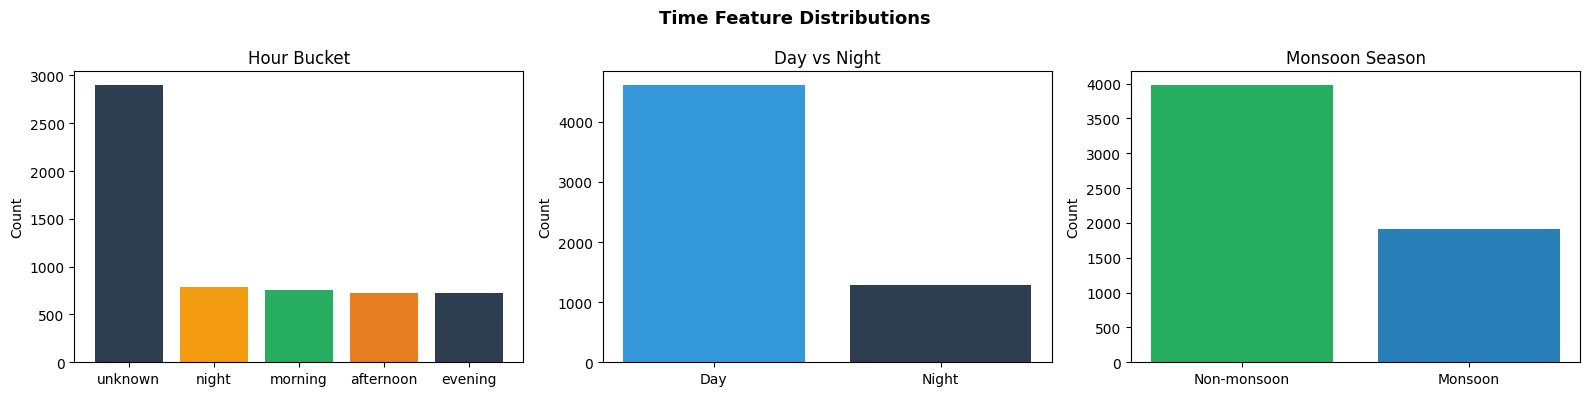

In [25]:
# Visualise time features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Time Feature Distributions", fontsize=13, fontweight="bold")

hb = df["hour_bucket"].value_counts()
axes[0].bar(hb.index, hb.values, color=["#2c3e50","#f39c12","#27ae60","#e67e22"])
axes[0].set_title("Hour Bucket")
axes[0].set_ylabel("Count")

axes[1].bar(["Day","Night"], [
    (df["is_night"]==0).sum(), (df["is_night"]==1).sum()
], color=["#3498db","#2c3e50"])
axes[1].set_title("Day vs Night")
axes[1].set_ylabel("Count")

axes[2].bar(["Non-monsoon","Monsoon"], [
    (df["is_monsoon"]==0).sum(), (df["is_monsoon"]==1).sum()
], color=["#27ae60","#2980b9"])
axes[2].set_title("Monsoon Season")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(PROCESSED / "fe_time_features.png", dpi=120)
plt.show()

### Risk Factor Features